In [116]:
import numpy as np
import pandas as pd

data = pd.read_csv('training_set.csv')
data

,feature1,feature2,feature3,feature4,feature5,Authenticated
0,0.599758,0.012166,0.209270,1.087926,4.088241,0
1,-5.512324,-0.426576,-0.092336,0.501431,3.844389,0
2,-3.387749,2.786477,0.195597,1.540859,4.148680,0
3,-4.690195,-1.024081,-0.101571,0.981619,3.712296,0
4,7.990252,0.398343,-0.302286,1.309536,3.870292,0
...,...,...,...,...,...,...
495,2.692383,-1.315251,0.544614,1.033572,3.509521,0
496,-2.109952,4.009235,0.160048,1.015621,3.559968,0
497,6.081859,-0.425740,0.045147,0.416322,4.223411,0
498,3.562751,5.979981,0.070664,1.481012,4.268754,0


In [118]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [126]:
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
# Apply UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embedding = reducer.fit_transform(X)

# Create a DataFrame for the UMAP results
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP_1', 'UMAP_2'])
umap_df['Authenticated'] = y_mapped.values

display(umap_df.head())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



,UMAP_1,UMAP_2,Authenticated
0,2.072439,4.762760,0
1,15.516118,10.144521,0
2,12.005551,6.554729,0
3,15.159857,9.933764,0
4,-2.710555,9.565664,0


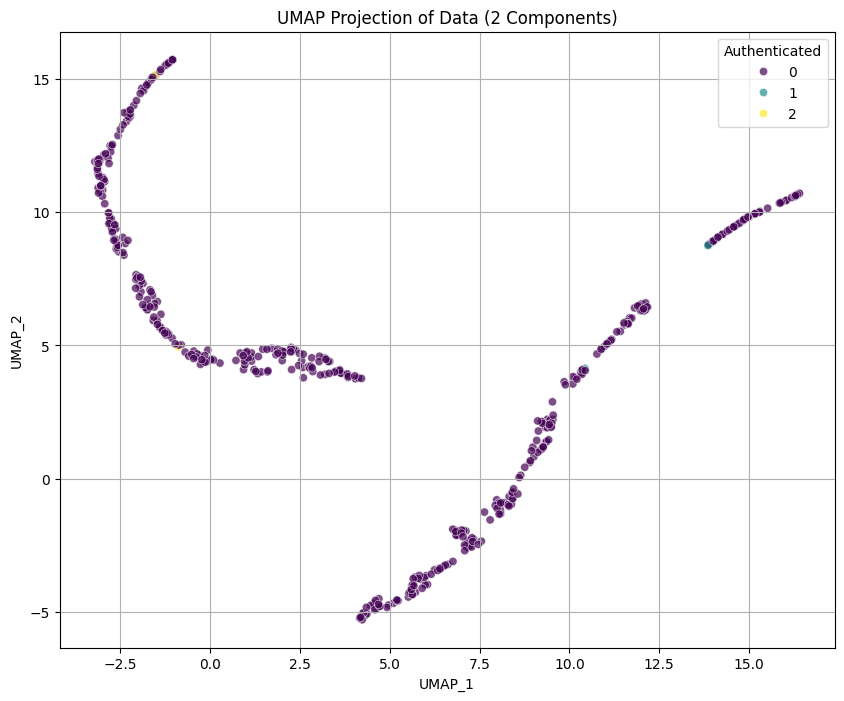

In [128]:
# Plot the 2D UMAP embedding
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='Authenticated',
    palette='viridis',
    data=umap_df,
    legend='full',
    alpha=0.7
)
plt.title('UMAP Projection of Data (2 Components)')
plt.xlabel('UMAP_1')
plt.ylabel('UMAP_2')
plt.grid(True)
plt.show()

In [119]:
unique_y_values = y.nunique()

if unique_y_values <= 2:

    if -1 in y.unique():
        y_binary = y.replace(-1, 1)
        X_train, X_test, y_train_binary, y_test_binary = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
        xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
        xgb_model.fit(X_train, y_train_binary)
    else:

        xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
        xgb_model.fit(X_train, y_train)
else:

    label_mapping = {label: i for i, label in enumerate(y.unique())}
    y_mapped = y.map(label_mapping)
    X_train, X_test, y_train_mapped, y_test_mapped = train_test_split(X, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped)

    xgb_model = XGBClassifier(objective='multi:softmax', num_class=unique_y_values, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
    xgb_model.fit(X_train, y_train_mapped)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[20:37:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




In [120]:
# Step 3: Make predictions on the test set
if 'y_test_binary' in locals():
    y_pred = xgb_model.predict(X_test)
    y_true = y_test_binary
elif 'y_test_mapped' in locals():
    y_pred = xgb_model.predict(X_test)
    y_true = y_test_mapped
else:
    y_pred = xgb_model.predict(X_test)
    y_true = y_test

# Step 4: Evaluate the model's performance
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.9900

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        99
           1       0.00      0.00      0.00         1

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100


Confusion Matrix:
[[99  0]
 [ 1  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [121]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get unique classes from the y_mapped target variable
unique_classes = np.sort(y_mapped.unique())

# Calculate the class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_mapped
)

# Convert the class_weights_array into a dictionary
class_weights_dict = dict(zip(unique_classes, class_weights_array))

print(f"Unique classes: {unique_classes}")
print(f"Computed class weights array: {class_weights_array}")
print(f"Computed class weights dictionary: {class_weights_dict}")

Unique classes: [0 1 2]
Computed class weights array: [ 0.33602151 83.33333333 83.33333333]
Computed class weights dictionary: {np.int64(0): np.float64(0.33602150537634407), np.int64(1): np.float64(83.33333333333333), np.int64(2): np.float64(83.33333333333333)}


In [122]:
from xgboost import XGBClassifier
import numpy as np


model = XGBClassifier(
    objective='multi:softmax',
    num_class=unique_y_values,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


sample_weights = np.array([class_weights_dict[label] for label in y_train_mapped])


model.fit(X_train, y_train_mapped, sample_weight=sample_weights)

print("XGBoost model re-trained successfully with class weights!")

XGBoost model re-trained successfully with class weights!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[20:37:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




In [123]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set using the weighted model
y_pred_weighted = model.predict(X_test)

# Evaluate the weighted model's performance
accuracy_weighted = accuracy_score(y_test_mapped, y_pred_weighted)
report_weighted = classification_report(y_test_mapped, y_pred_weighted)
conf_matrix_weighted = confusion_matrix(y_test_mapped, y_pred_weighted)

print(f"Weighted Model Accuracy: {accuracy_weighted:.4f}")
print("\nWeighted Model Classification Report:")
print(report_weighted)
print("\nWeighted Model Confusion Matrix:")
print(conf_matrix_weighted)


Weighted Model Accuracy: 0.9900

Weighted Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        99
           1       0.00      0.00      0.00         1

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100


Weighted Model Confusion Matrix:
[[99  0]
 [ 1  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [124]:
val_data=pd.read_csv('validation_set.csv')
test_data=pd.read_csv('test_set.csv')


val_labels=model.predict(val_data.drop(['SampleID'], axis=1))
val_labels*=-1
test_labels=model.predict(test_data.drop(['SampleID'], axis=1))
test_labels*=-1
val_df = pd.DataFrame({
    "SampleID": val_data["SampleID"],
    "ClasamentType": "A",
    "label": val_labels
})

test_df = pd.DataFrame({
    "SampleID": test_data["SampleID"],
    "ClasamentType": "B",
    "label": test_labels
})

submission = pd.concat([val_df, test_df], ignore_index=True)

submission.to_csv("submission.csv", index=False)

submission.head()

,SampleID,ClasamentType,label
0,VALIDATION_001,A,0
1,VALIDATION_002,A,0
2,VALIDATION_003,A,0
3,VALIDATION_004,A,0
4,VALIDATION_005,A,0
